# Análise Exploratória de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# adiciona a raiz do projeto ao caminho de busca do Python
sys.path.append(str(Path().resolve().parent))

colors = ["#9467bd", "#057476", "#FF7A00"]
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette(colors))

## 1. Leitura do conjunto de dados

In [2]:
df_train = pd.read_csv('../data/processed/train_clean.csv')
display(df_train)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Standard,809.98,26.822620,265,0,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,February,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,219,0,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,March,33,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,267,0,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,April,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,268,0,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,May,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,269,0,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,April,25,Mechanic,39628.99,3359.415833,4,6.0,7.0,2,"Auto Loan, Student Loan",...,Standard,502.38,34.663572,378,0,35.104023,60.971333,High_spent_Large_value_payments,479.866228,Poor
99996,May,25,Mechanic,39628.99,3359.415833,4,6.0,7.0,2,"Auto Loan, Student Loan",...,Standard,502.38,40.565631,379,0,35.104023,54.185950,High_spent_Medium_value_payments,496.651610,Poor
99997,June,25,Mechanic,39628.99,3359.415833,4,6.0,13.0,2,"Auto Loan, Student Loan",...,Good,502.38,41.255522,380,0,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,July,25,Mechanic,39628.99,3359.415833,4,6.0,7.0,2,"Auto Loan, Student Loan",...,Good,502.38,33.638208,381,0,35.104023,251.672582,Low_spent_Large_value_payments,319.164979,Standard


## 2. Descrição dos dados

[Credit score classification](https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data) é um conjunto de dados com informações relacionadas a crédito bancário, onde o objetivo é construir um modelo de aprendizado de máquina para automatizar a classificação de pontuação de crédito dos clientes. O dataset possui informações como idade, profissão, salário, número de cartões e contas, taxa de juros, comportamento de pagamento, e outras informações de crédito do cliente. Além disso, **cada entrada representa um registro mensal do histórico de financeiro de um cliente**.

> Conjunto de dados de teste possui 100.000 instâncias e 24 variáveis, incluindo a variável preditora `Credit_Score`

### 2.1 Dicionário de dados

In [3]:
dicionario = pd.read_csv('../data/external/dictionary.csv')

# forçando pandas a mostrar todo o conteúdo das células
pd.set_option('display.max_colwidth', None)

dicionario = dicionario.query("Papel != 'identificador'")

# salvando o dicionario de dados sem variáveis identificadoras
dicionario.to_csv('../data/external/dictionary_no_identifiers.csv')

dicionario

,Variável,Tipo,Subtipo,Papel,Descrição
2,Month,categórica,ordinal,preditora,Mês do ano
4,Age,numérica,discreta,preditora,Idade do cliente
6,Occupation,categórica,nominal,preditora,Ocupação do cliente
7,Annual_Income,numérica,contínua,preditora,Renda anual do cliente
8,Monthly_Inhand_Salary,numérica,contínua,preditora,Salário base mensal do cliente
9,Num_Bank_Accounts,numérica,discreta,preditora,Número de contas bancárias que o cliente possui
10,Num_Credit_Card,numérica,discreta,preditora,Número de outros cartões de crédito detidos por um cliente
11,Interest_Rate,numérica,discreta,preditora,Taxa de juros do cartão de crédito
12,Num_of_Loan,numérica,discreta,preditora,Número de empréstimos feitos no banco pelo cliente
13,Type_of_Loan,categórica,nominal,preditora,Tipos de empréstimo tomados por um cliente


In [4]:
dicionario['Tipo'].value_counts()

Tipo
numérica      17
categórica     7
Name: count, dtype: int64

In [5]:
dicionario['Subtipo'].value_counts()

Subtipo
discreta    9
contínua    8
ordinal     3
nominal     3
binária     1
Name: count, dtype: int64

In [6]:
dicionario['Papel'].value_counts()

Papel
preditora    23
alvo          1
Name: count, dtype: int64

---
No conjunto de dados limpo, as variáveis presentes são das seguintes categorias:
- Há 17 variáveis numéricas, sendo 9 delas discretas e 8 contínuas
- 7 variáveis são categóricas, sendo 3 nominais, 3 ordinais e 1 binária
- Há 23 variáveis preditoras e 1 variável alvo da predição
---

## 3. Perguntas de partida

- Ainda existem dados faltantes no conjunto de dados?
- Qual é a distribuição dos dados categóricos?
- Qual é a distribuição dos dados numéricos?
- Existem dados discrepantes? Se sim, em quais variáveis?
- Qual é a correlação das variáveis preditoras com a variável alvo?

### 3.1 Ainda existem dados faltantes no conjunto de dados?

In [7]:
df_train.isna().sum()

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Months       0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

> **Não há dados faltantes** no conjunto de dados, devido à limpeza feita na etapa anterior.

### 3.2 Qual é a distribuição dos dados categóricos?

Abaixo estão gráficos de barras verticais para as variáveis que possuem menos categorias e que suas categorias têm nomes menos extensos.

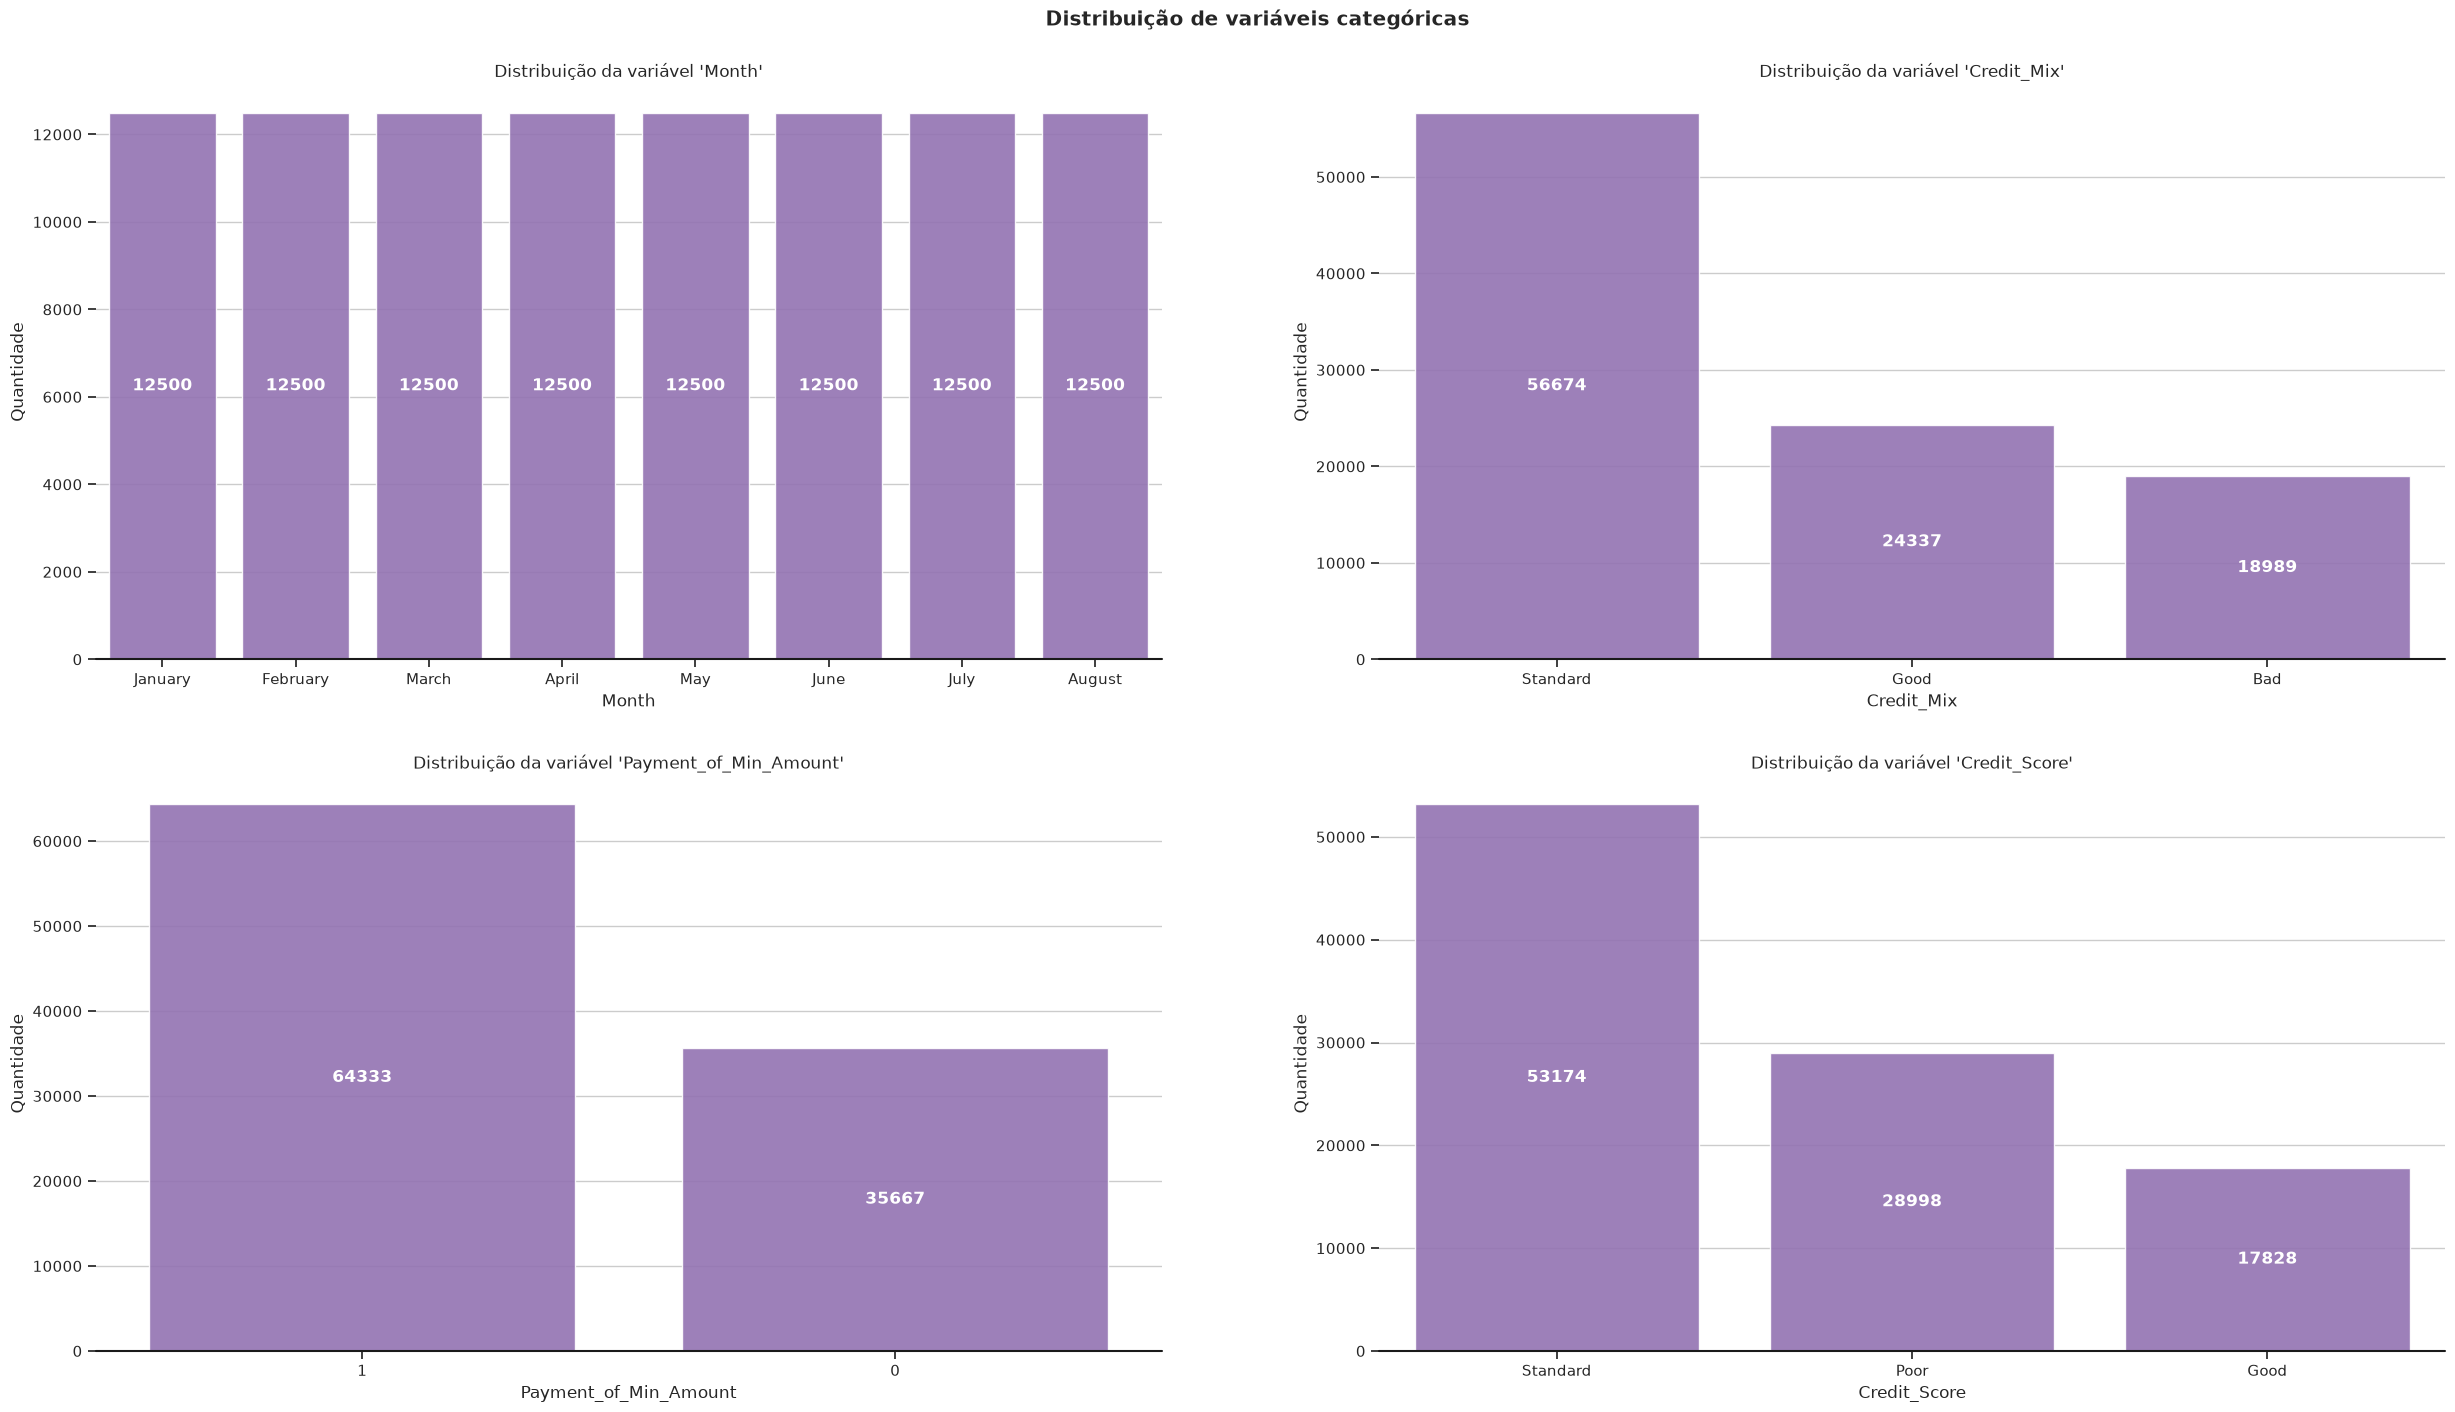

In [8]:
import src.construir_graficos.graficos_categoricos as graficos

graficos.variaveis_categoricas(df_train, dicionario)

Tipos de Credit_Mix:
- Good: o cliente possui uma combinação de créditos considerada saudável e diversificada.
- Standard: a combinação de créditos é intermediária.
- Bad: a combinação de créditos é considerada desfavorável.

A seguir estão os gráficos de barras horizontais para as variáveis que têm categorias com nomes mais extensos e que estão em maior número:

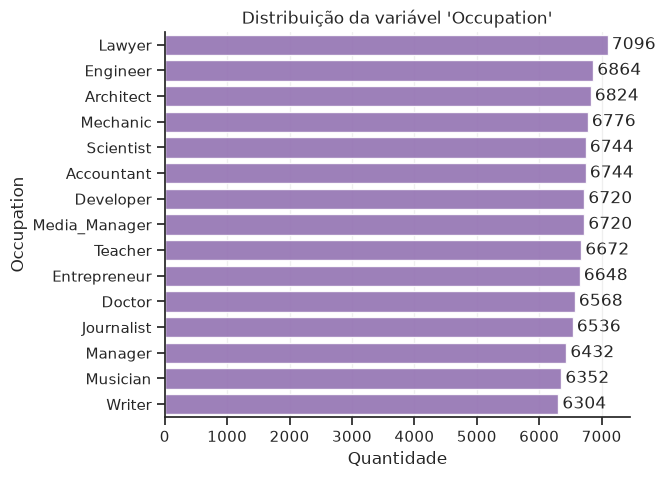

In [9]:
graficos.variavel_categorica(df_train, 'Occupation', 6, 5)

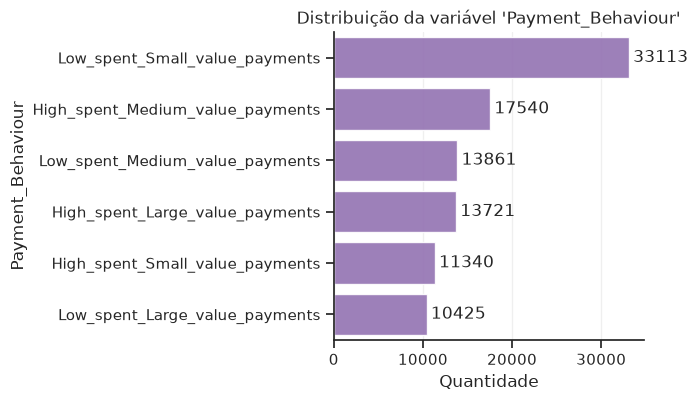

In [10]:
graficos.variavel_categorica(df_train, 'Payment_Behaviour', 4, 4)

Tipos de comportamento de pagamento:

- **Pagamentos de pequeno valor e baixo gasto**: o cliente gasta pouco e faz pagamentos de pequeno valor
- **Pagamentos de médio valor e baixo gasto**: o cliente gasta pouco e faz pagamentos de pequeno médio
- **Pagamentos de alto valor e baixo gasto**: o cliente gasta pouco e faz pagamentos de alto valor
- **Pagamentos de pequeno valor e alto gasto**: o cliente gasta muito e faz pagamentos de pequeno valor
- **Pagamentos de médio valor e alto gasto**: o cliente gasta muito e faz pagamentos de médio valor
- **Pagamentos de alto valor e alto gasto**: o cliente gasta muito e faz pagamentos de alto valor

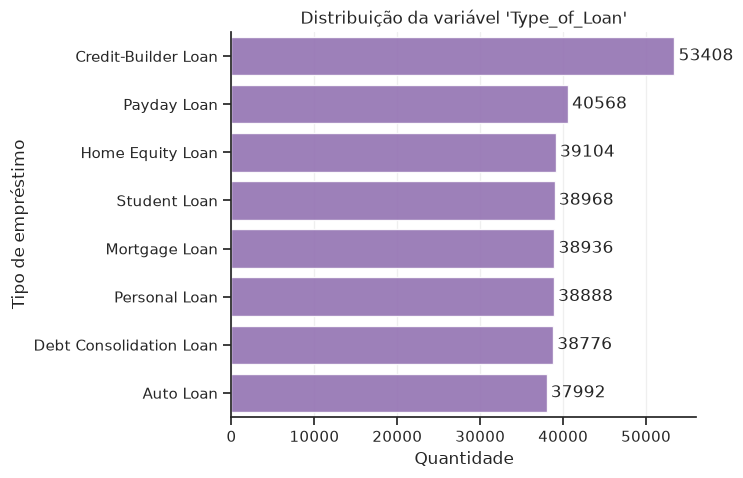

In [11]:
graficos.type_of_loan(df_train)

Tipos de empréstimos:
- Empréstimo para Construção de Crédito
- Empréstimo de Curto Prazo
- Empréstimo com Garantia Imobiliária
- Empréstimo Estudantil
- Empréstimo Hipotecário
- Empréstimo Pessoal
- Empréstimo para Consolidação de Dívidas
- Empréstimo Automotivo

---
- Há registros mensais de clientes dos meses de janeiro a agosto, e há a mesma quantiadade de registros para cada mês (12.500)
- A maioria dos registros de clientes possui uma combinação de créditos (Credit_Mix) considerada **intermediária**, enquanto a minoria possui uma combinação considerada desfavorável.
- A maioria dos clientes **pagou o valor mínimo** exigido da sua fatura de crédito nos meses correspondentes.
- A maioria das pontuações de crédito registradas são da categoria **'Standard'** (Padrão), enquanto a minoria é classificada como 'Good' (Boa).
- A maioria dos registros são de clientes na profissão de **advogados**, seguidos por engenheiro e arquiteto. A quantidade de registros em cada profissão tem valores parecidos, variando apenas de 6304 a 7096.
- A maioria dos registros dos clientes têm comportamento de **gastar pouco e fazer pagamentos de valores pequenos**, enquanto a minoria gasta pouco e faz pagamentos de valores altos.
- A maioria dos registros de empréstimos tomados é de **empréstimos para construção de crédito**, e a minoria é de empréstimo automotivo.
---

### 3.3 Qual é a distribuição dos dados numéricos?

In [12]:
df_train.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.00000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,33.31899,1.764157e+05,4197.328114,5.364180,5.522130,14.515560,3.511000,21.188290,13.475410,10.368345,5.757840,1426.220376,32.285173,220.997160,0.643330,1403.118217,614.951381,401.755494
std,10.64554,1.429618e+06,3186.918569,2.575733,2.048036,8.712266,2.397302,14.752957,5.983353,6.719627,3.813364,1155.129026,5.116875,95.133546,0.479019,8306.041270,1999.726647,212.750017
min,14.00000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-6.490000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.000000,0.007760
25%,25.00000,1.945750e+04,1626.719792,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.420000,3.000000,566.072500,28.052567,154.000000,0.000000,30.306660,77.017414,270.913865
50%,33.00000,3.757861e+04,3092.270000,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,1.000000,69.249473,135.925682,336.731225
75%,41.00000,7.279092e+04,5958.695625,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.660000,8.000000,1945.962500,36.496663,292.000000,1.000000,161.224249,255.038698,467.670597
max,118.00000,2.419806e+07,15204.633333,18.000000,20.000000,100.000000,19.000000,67.000000,98.000000,36.970000,49.000000,4998.070000,50.000000,404.000000,1.000000,82331.000000,10000.000000,1602.040519


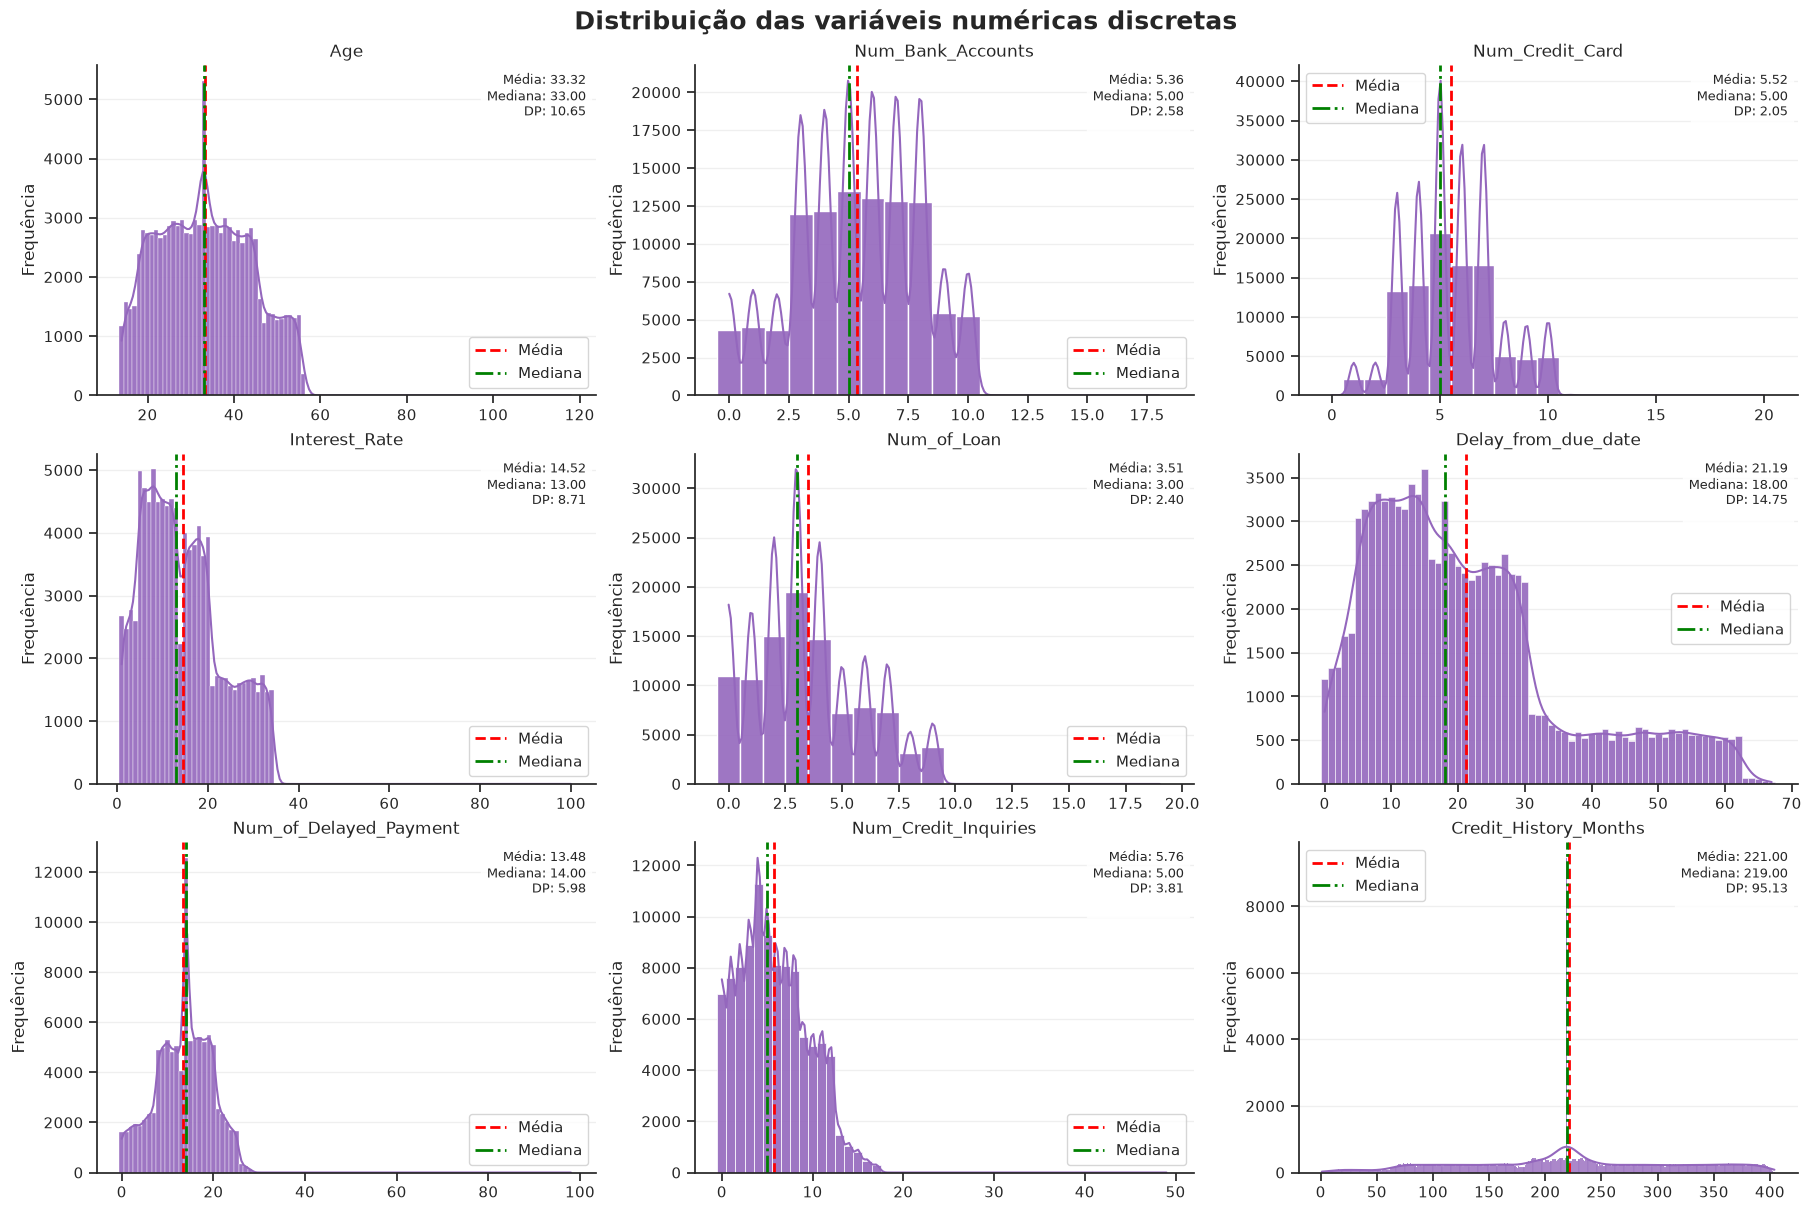

In [13]:
import src.construir_graficos.graficos_numericos as graficos_num

graficos_num.variaveis_discretas(df_train, dicionario)

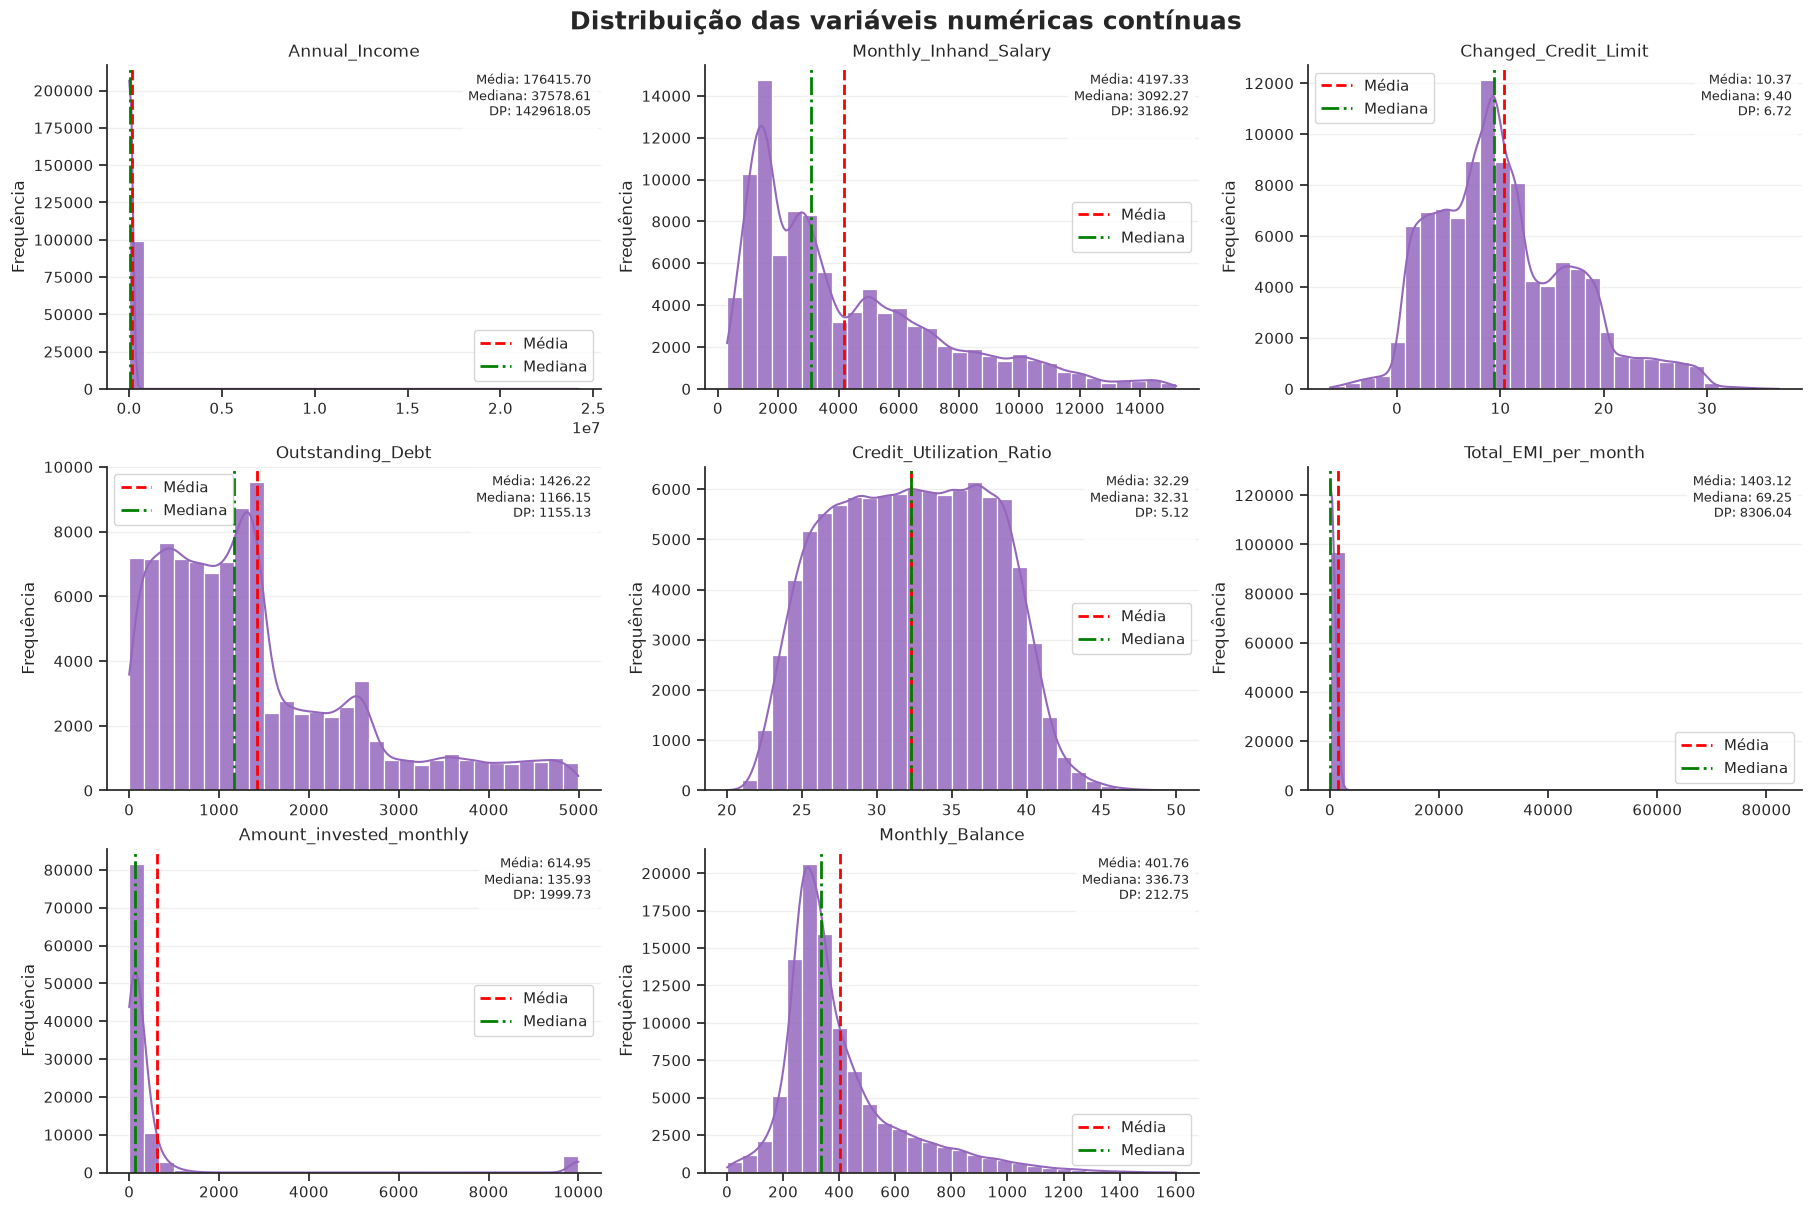

In [14]:
graficos_num.plot_variaveis_continuas(df_train, dicionario)

---
- A idade dos clientes está concentrada entre 14 e pouco menos de 60 anos, porém ainda existem registros discrepantes que ultrapassam essa faixa de idade.
- A frequência maior da quantidade de contas bancárias e cartões de crédito possuídas pelos clientes está entre 3 e 8.
- A taxa de juros (Interest_Rate) dos clientes é assimétrica positiva. Os valores se concentram entre 5% e 20%, mas existem alguns valores superiores a isso e que atingem até 100%
- A maioria dos clientes possui de 2 a 5 empréstimos
- A maioria dos clientes atrasa o pagamento de 5 a 30 dias, mas existe uma quantidade considerável de clientes que atrasa mais do que isso. Além disso, a maioria dos clientes tem de 9 a 20 pagamentos atrasados.
- Tanto para salários anuais como mensais, há poucas pessoas com salários muito acima da mediana. Além disso, poucos clientes investem mensalmente um valor muito alto.
- Há clientes com uma dívida muito superior à da maioria.

---

### 3.3 Existem dados discrepantes? Se sim, em quais variáveis?

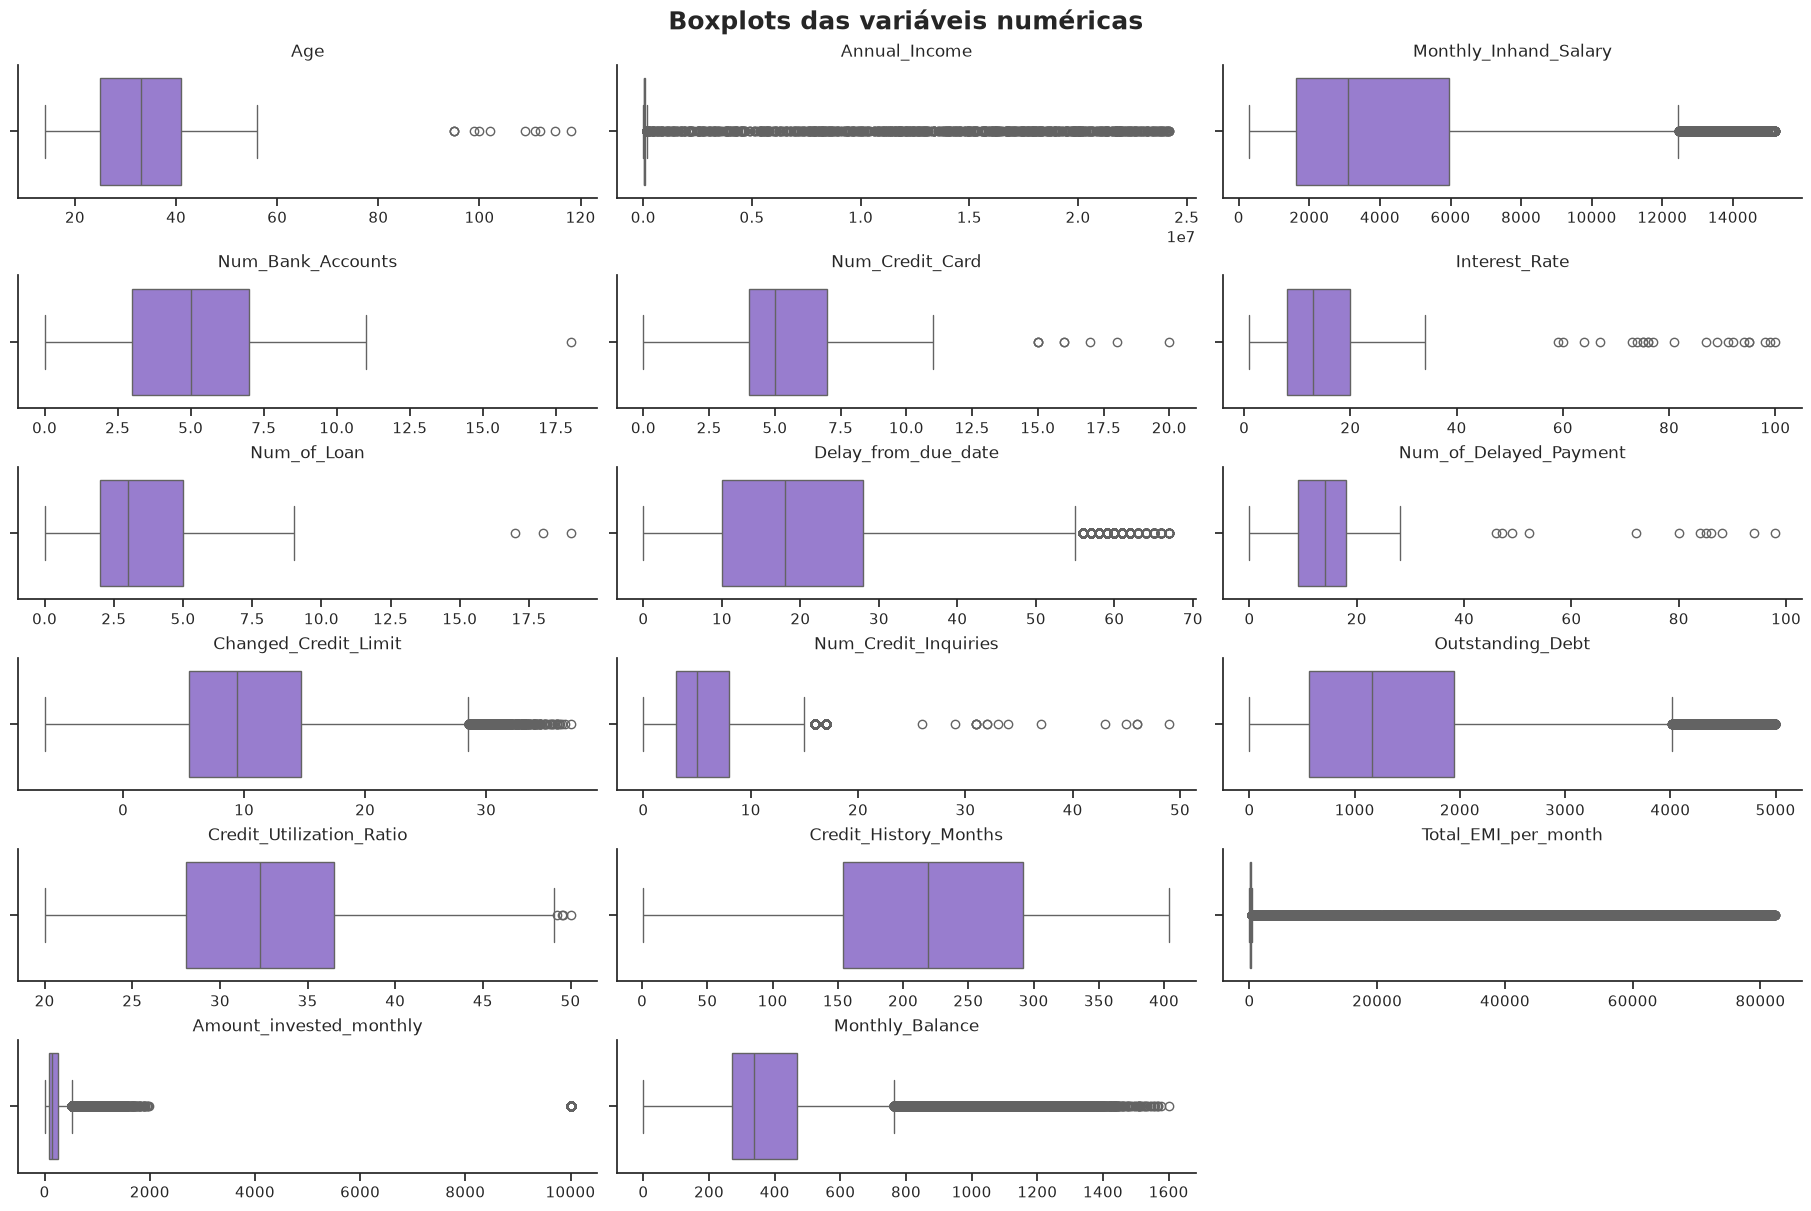

In [15]:
import src.construir_graficos.outliers as outliers

outliers.boxplots(df_train, dicionario)

In [16]:
outliers.resumo_outliers(df_train, dicionario)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers,% Outliers
15,Amount_invested_monthly,77.017414,255.038698,178.021284,-190.014512,522.070624,10866,10.87
16,Monthly_Balance,270.913865,467.670597,196.756732,-24.221234,762.805696,7864,7.86
14,Total_EMI_per_month,30.306660,161.224249,130.917589,-166.069722,357.600632,6795,6.80
11,Outstanding_Debt,566.072500,1945.962500,1379.890000,-1503.762500,4015.797500,5272,5.27
7,Delay_from_due_date,10.000000,28.000000,18.000000,-17.000000,55.000000,4002,4.00
1,Annual_Income,19457.500000,72790.920000,53333.420000,-60542.630000,152791.050000,2783,2.78
2,Monthly_Inhand_Salary,1626.719792,5958.695625,4331.975833,-4871.243958,12456.659375,2016,2.02
9,Changed_Credit_Limit,5.420000,14.660000,9.240000,-8.440000,28.520000,1177,1.18
10,Num_Credit_Inquiries,3.000000,8.000000,5.000000,-4.500000,15.500000,756,0.76
5,Interest_Rate,8.000000,20.000000,12.000000,-10.000000,38.000000,22,0.02


> Apenas a variável Credit_History_Months não possui nenhum outlier.

As taxas mais altas de outliers estão nas variáveis:
- Amount_invested_monthly
- Monthly_Balance
- Total_EMI_per_month
- Outstanding_Debt
- Delay_from_due_date

### 3.4 Qual é a correlação das variáveis numéricas entre si?

Nesta estapa, construímos uma matriz de correlação associada com um mapa de calor (heatmap) para visulaizar as correlações positivas ou negativas das variáveis numéricas preditoras. Para isso, utilizaremos a correlação de Spearman, que é mais robusta diante outliers.

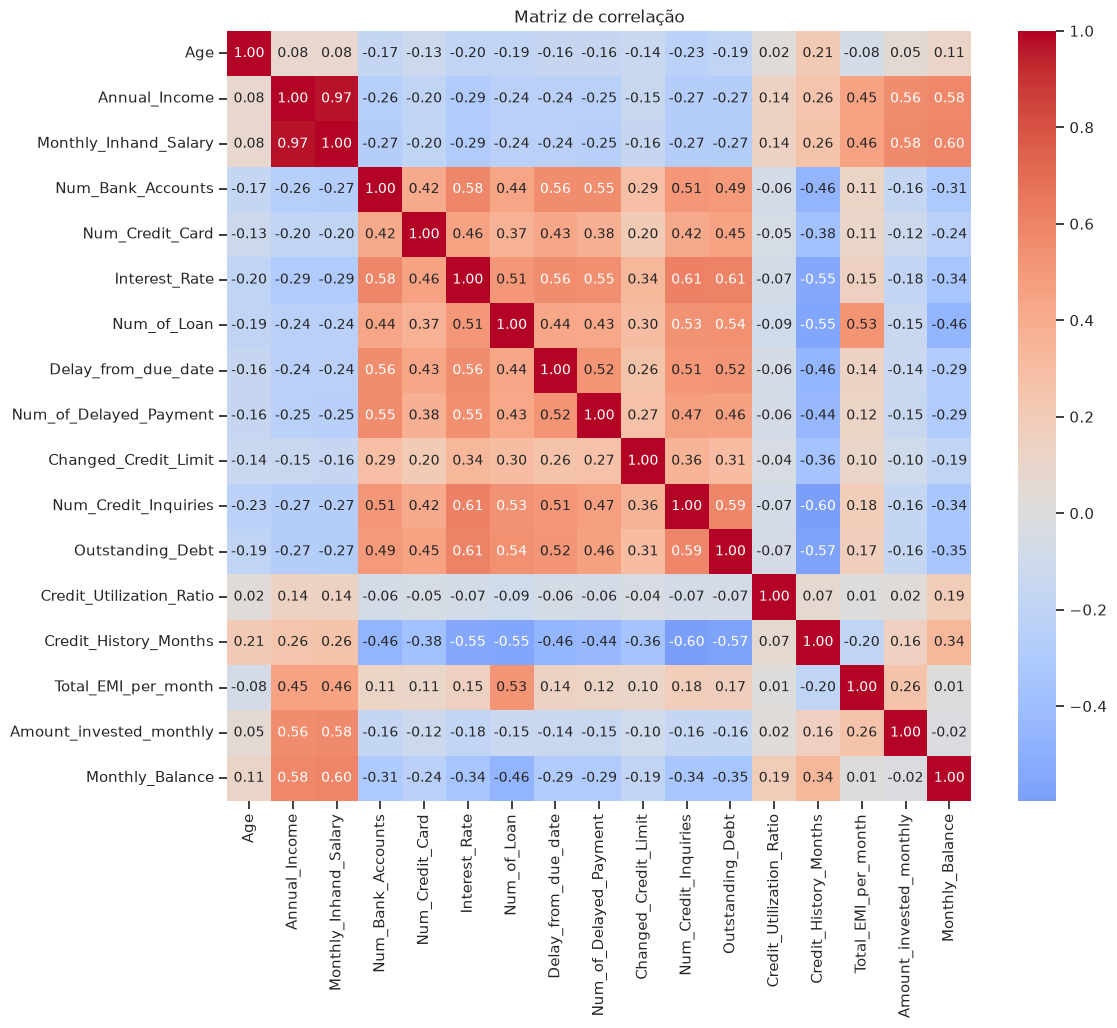

In [17]:
import src.construir_graficos.correlacao as correlacao

correlacao.heatmap(df_train, dicionario)

- `Annual_Income` está fortemente relacionado a `Monthly_Inhand_Salary` (correlação de 0,97), pois ambos representam dados de salários dos clientes (o primeiro representando o salário anual, e o segundo o salário base mensal). Se alguma delas for ser removida posteriormente para não atrapalhar um modelo sensível a multicolinearidade (modelos lineares), é preferível manter Annual_Income, pois ela não possuía dados nulos no dataset original.
- As variáveis `Monthly_Inhand_Salary` e `Monthly_Balance` tem uma correlação positiva moderada (0,60). Valores maiores de salário mensal tendem a estar associados a maiores saldos mensais, embora haja considerável variabilidade.
- O mesmo tende a acontecer entre `Interest_Rate` e as variáveis `Changed_Credit_Limit`, `Num_Credit_Inquiries` e `Num_Bank_Accounts`. Quanto maior a taxa de juros, mais variam os limites do cartão de crédito, aumentam as consultas de cartão de crédito feitas, e mais contas bancárias o cliente tembém, porém há variabilidade nos dados.
- Há também moderada correlação negativa entre variáveis, principalmente entre `Credit_History_Months`, `Num_Credit_Inquiries` e `Outstanding_Debt`. Quanto mais velho o histórico de crédito da pessoa, menor tende a ser as consultas de cartão de crédito e a dívida restante a ser paga, embora isso não seja uma regra.
- Além disso, quanto mais velho o histórico de créditos, menor tende a ser a taxa de juros e a quantidade de empréstimos tomados, configurando uma correlação negativa moderada.

### 3.5 Qual a correlação das variáveis numéricas com a variável alvo?

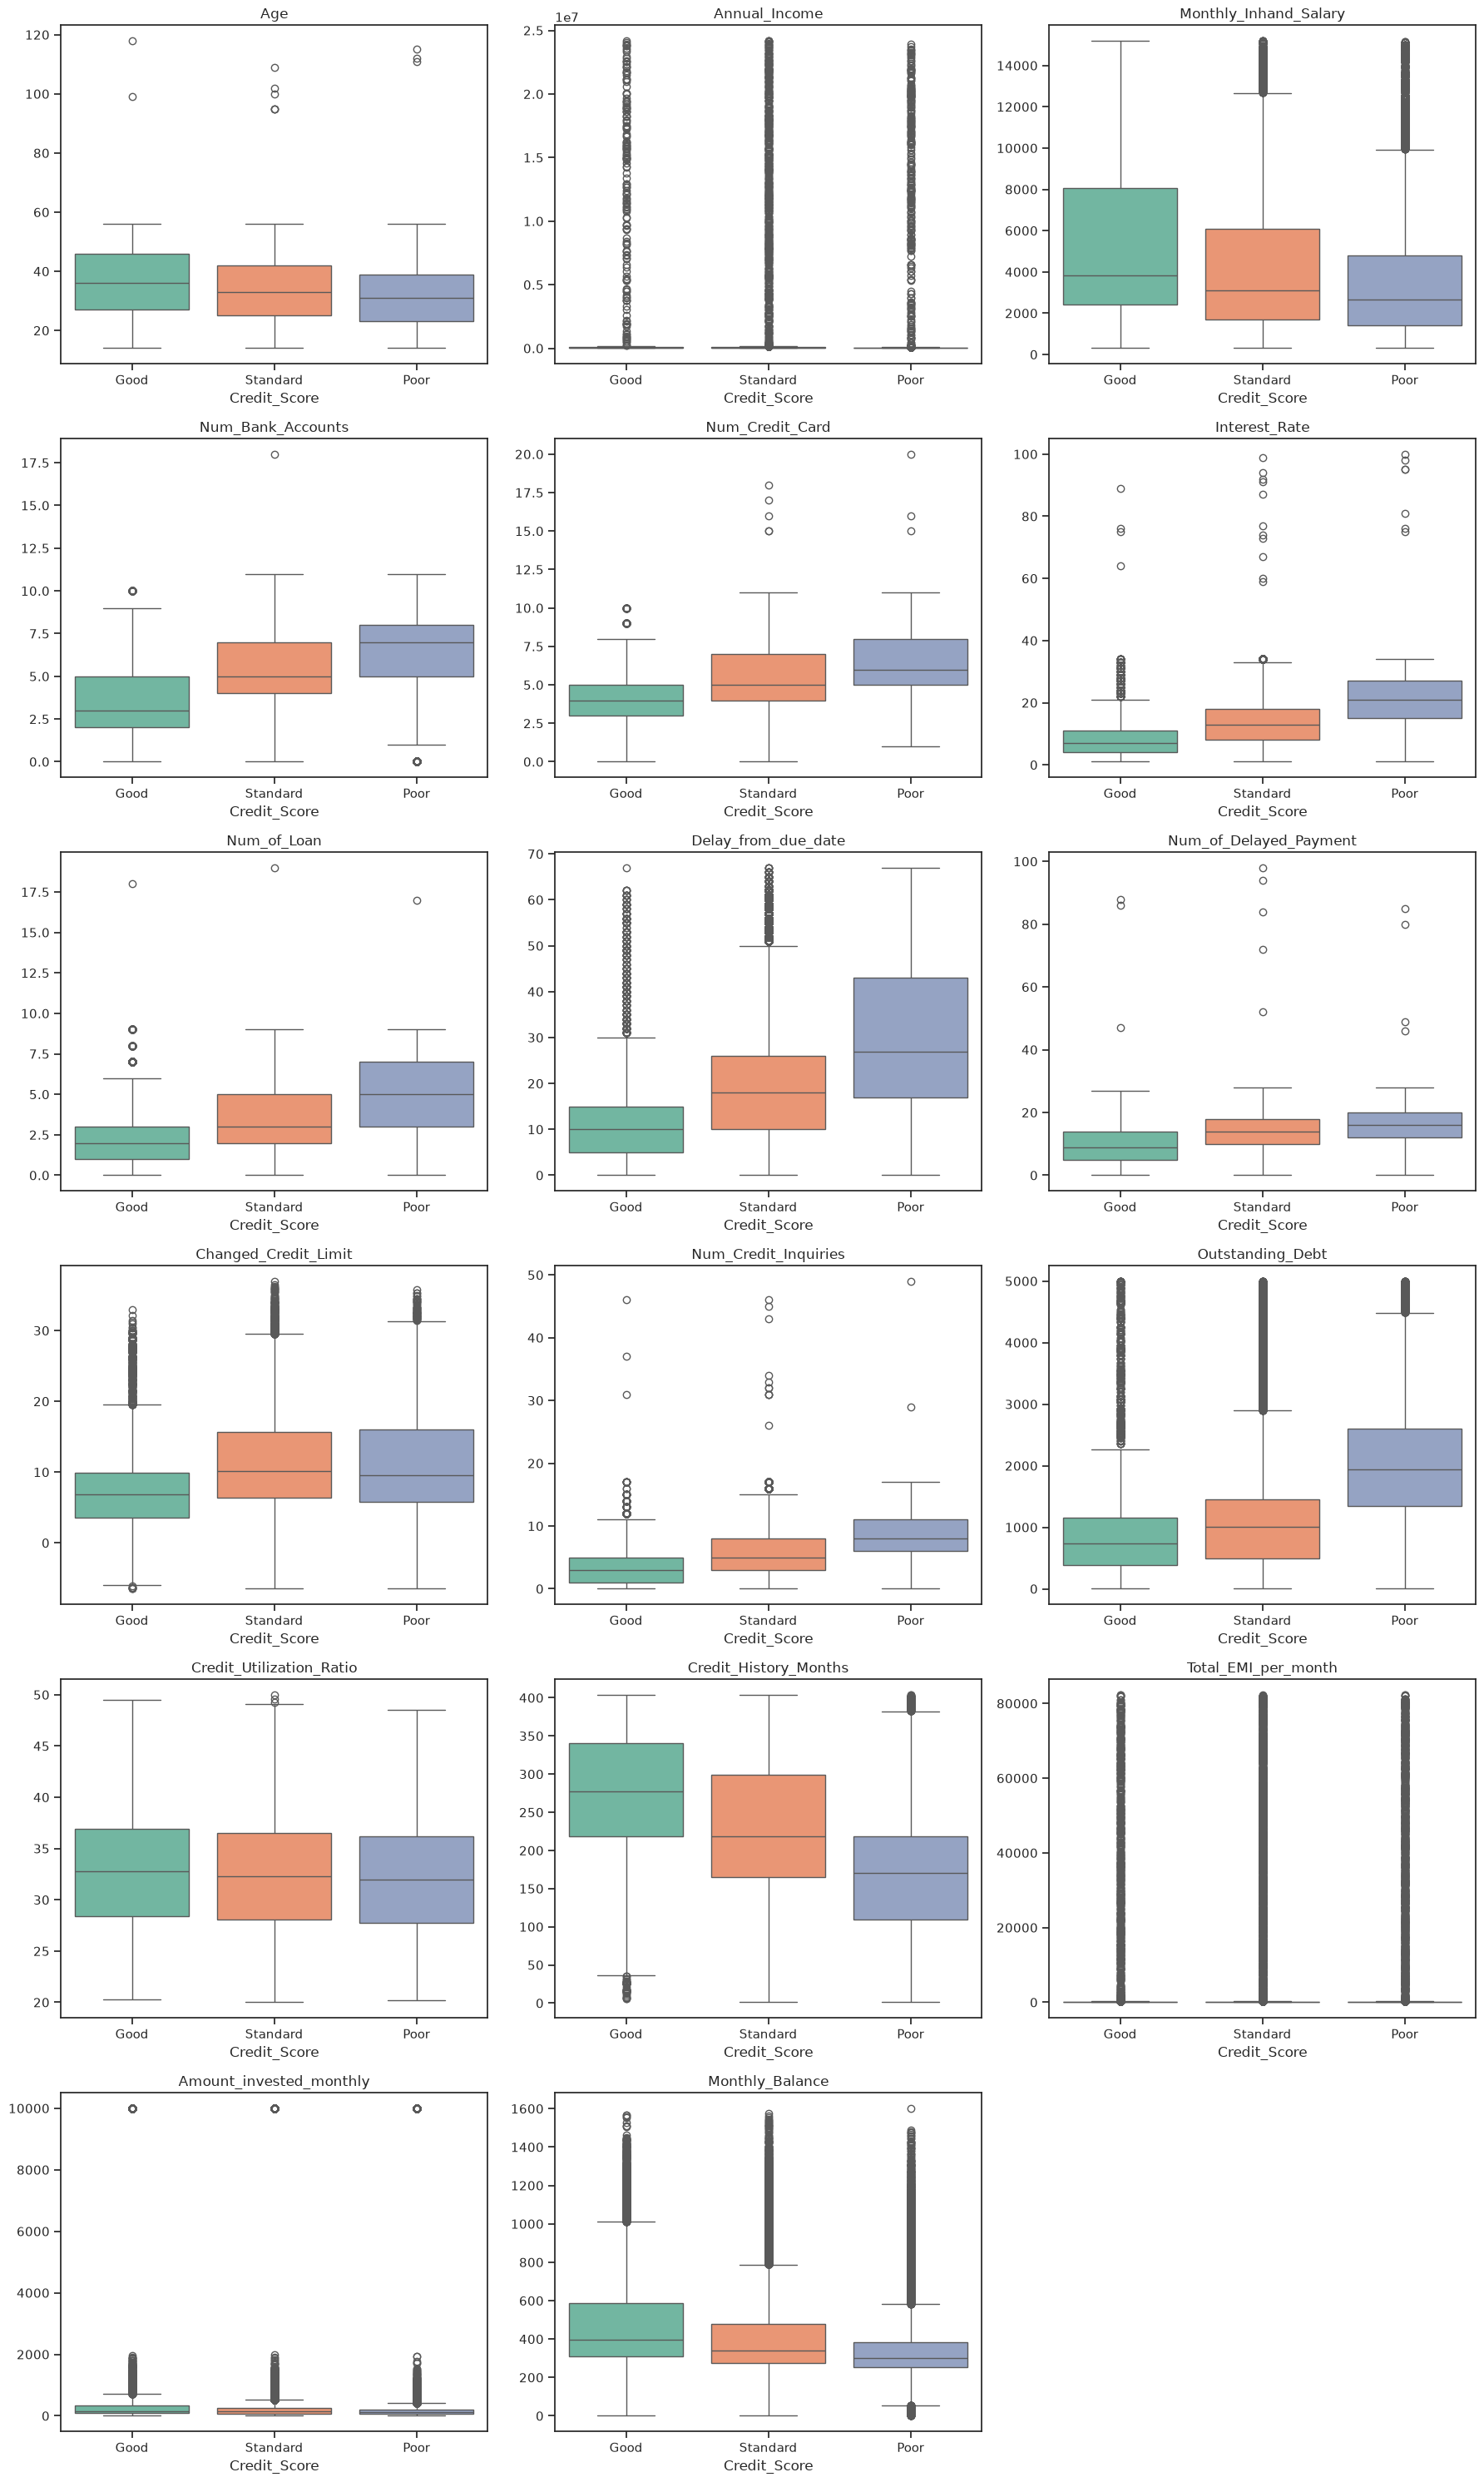

In [18]:
correlacao.boxplots_por_alvo(df_train, dicionario)

- Pessoas com **melhores scores de crédito** tendem a ter: um salário mensal maior, menos contas bancárias, menos cartões de crédito, menores taxas de juros, menores quantidades de empréstimos, ter menos tempo de atraso e número de atraso de pagamentos, ter menos consultas de cartão de crédito, ter uma dívida restante menor, ter o histórico de crédito mais antigo, ter um saldo mensal maior. Além disso, clientes com melhor classificação de crédito tendem a ser ligeiramente mais velhos, porém a idade, isoladamente, não separa bem as classes devido à grande sobreposição entre suas distribuições.
- Pelos gráficos, a idade, a taxa de utilização do cartão de crédito e a a variação percentual no limite do cartão de crédito parecem **não possuir um poder discriminatório alto**.
- Em contrapartida, a taxa de juros, idade do histórico de créditos, atraso do dia de pagamento e dívida remanescente parecem ter **alto poder discriminatório**.

> Faremos novos boxplots em escala logaritmica para as três variáveis que ficaram impossíveis de serem visualizadas nos boxplots anteriores

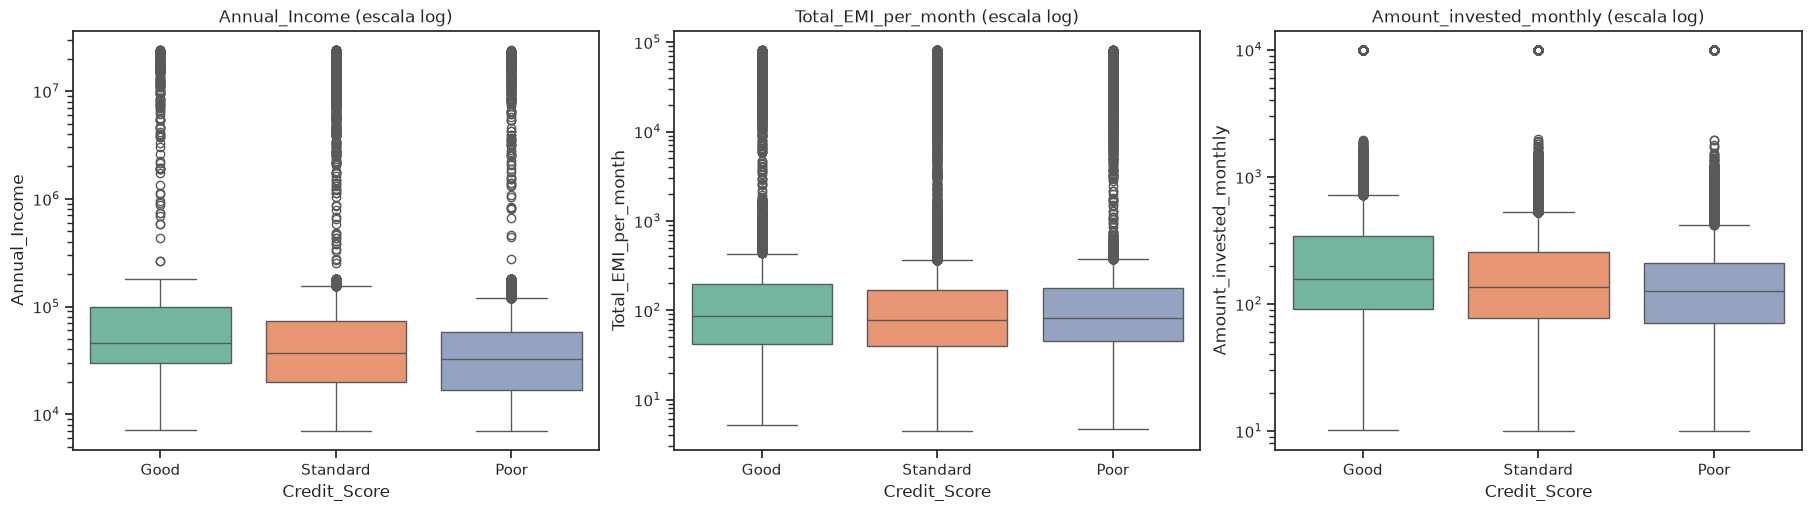

In [19]:
correlacao.boxplots_logaritmicos(df_train)

A renda anual, pagamentos mensais do EMI e valor mensal investido pelo cliente parecem não interferir muito no score de crédito, apesar que clientes com bons scores possuem renda e investimentos timidamente maiores.

### 3.6 Qual a correlação das variáveis categóricas com a variável alvo?

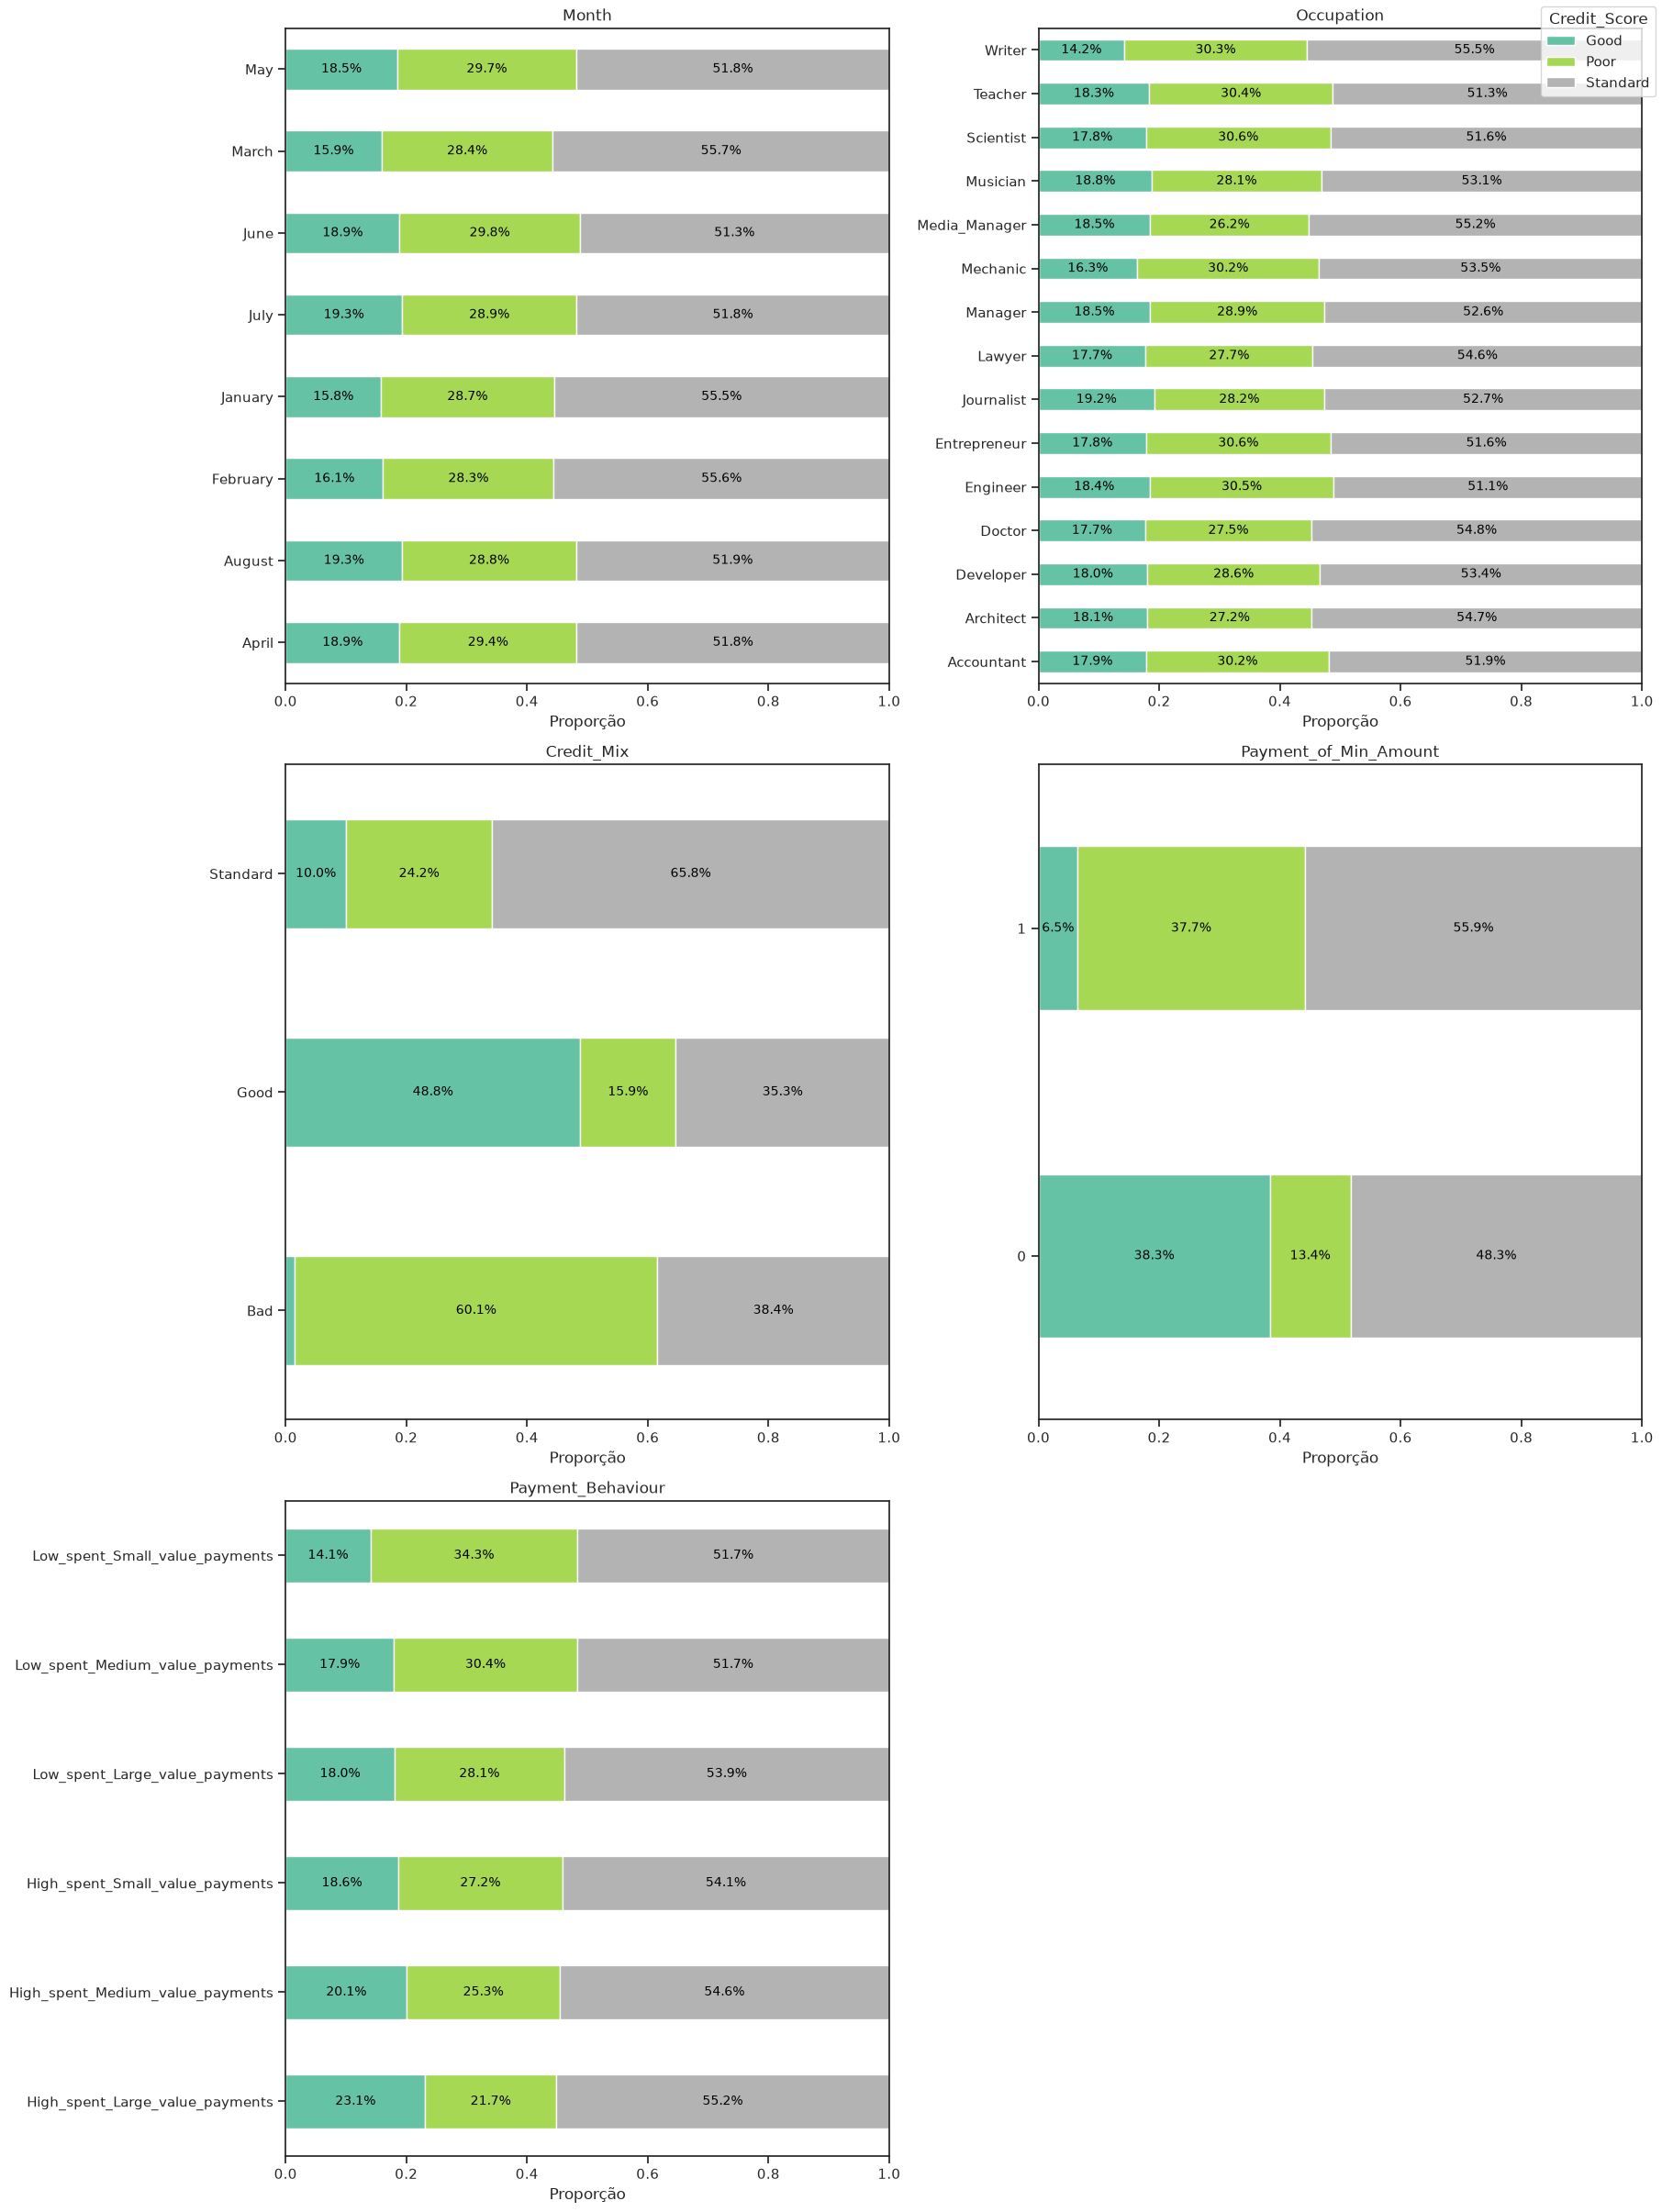

In [20]:
correlacao.categoricas_por_alvo(df_train, dicionario)

- A classificação do mix de créditos da pessoa parece influenciar no score de crédito: pessoas com mix de crédito bom tendem a ter um bom score de crédito, enquanto a maioria de pessoas com mix de crédito ruim tem um score de crédito pobre.
- Clientes que pagaram apenas o valor mínimo da sua fatura de crédito têm predominantemente um score padrão ou pobre. Em contrapartida, aqueles que pagam valores superiores ao mínimo apresentam maior frequência de bons scores de crédito.
- Clientes que gastam mais e realizam pagamentos de maior valor tendem a apresentar maior proporção de bons scores, enquanto aqueles com pagamentos pequenos concentram maior frequência da classe Poor.

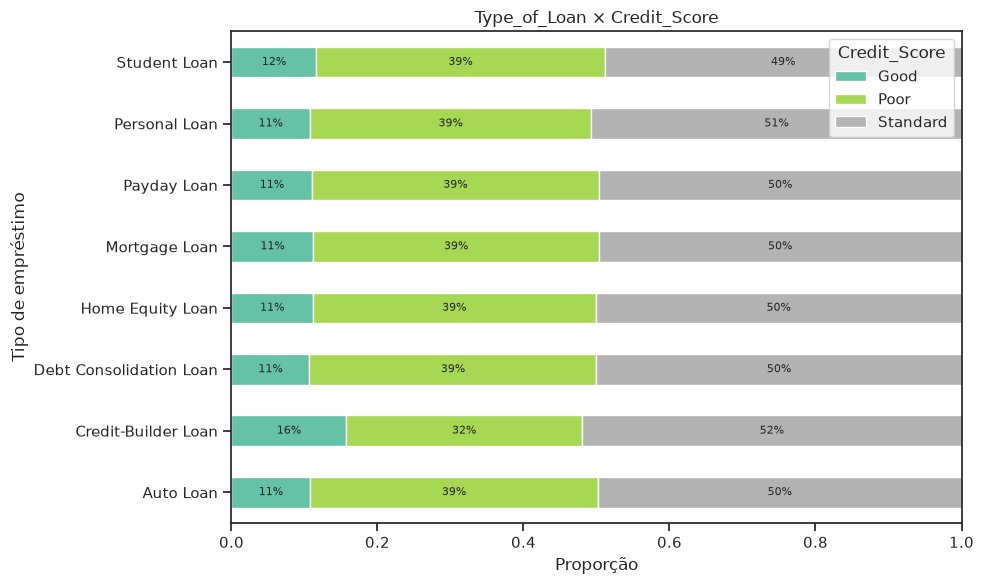

In [21]:
correlacao.type_of_loan_por_alvo(df_train)

- O tipo de empréstimo isolado tomado por um cliente parece não influenciar muito na classificação de pontuação de crédito, exceto o tipo de **empréstimo para construção de crédito**, que tem uma proporção de clientes com pontuação boa de crédito ligeiramente maior do que as outras categorias.

## 4. Conclusões

A partir das observações feitas com o auxílio dos gráficos de barras, histogramas, boxplots e matriz de correlação, as informações mais relevantes que conseguimos adquirir são:

- As variáveis que mais possuem dados discrepantes são: `Amount_invested_monthly`, `Monthly_Balance`, `Total_EMI_per_month`, `Outstanding_Debt`.
- Há registros mensais de clientes dos meses de janeiro a agosto, e eles estão na mesma quantidade.
- A maioria dos registros dos clientes têm comportamento de **gastar pouco e fazer pagamentos de valores pequenos**, enquanto a minoria gasta pouco e faz pagamentos de valores altos.
- A maioria dos clientes possui de 2 a 5 empréstimos.
- `Annual_Income` está fortemente correlacionado a `Monthly_Inhand_Salary`, o que faz sentido por ambos representarem dados salariais de clientes.
- A idade, a taxa de utilização do cartão de crédito e a a variação percentual no limite do cartão de crédito parecem **não possuir um poder discriminatório alto**.
- A taxa de juros, idade do histórico de créditos, atraso do dia de pagamento e dívida remanescente parecem ter **alto poder discriminatório**.
- Pessoas com mix de crédito bom tendem a ter um bom score de crédito, enquanto a maioria de pessoas com mix de crédito ruim tem um score de crédito pobre.